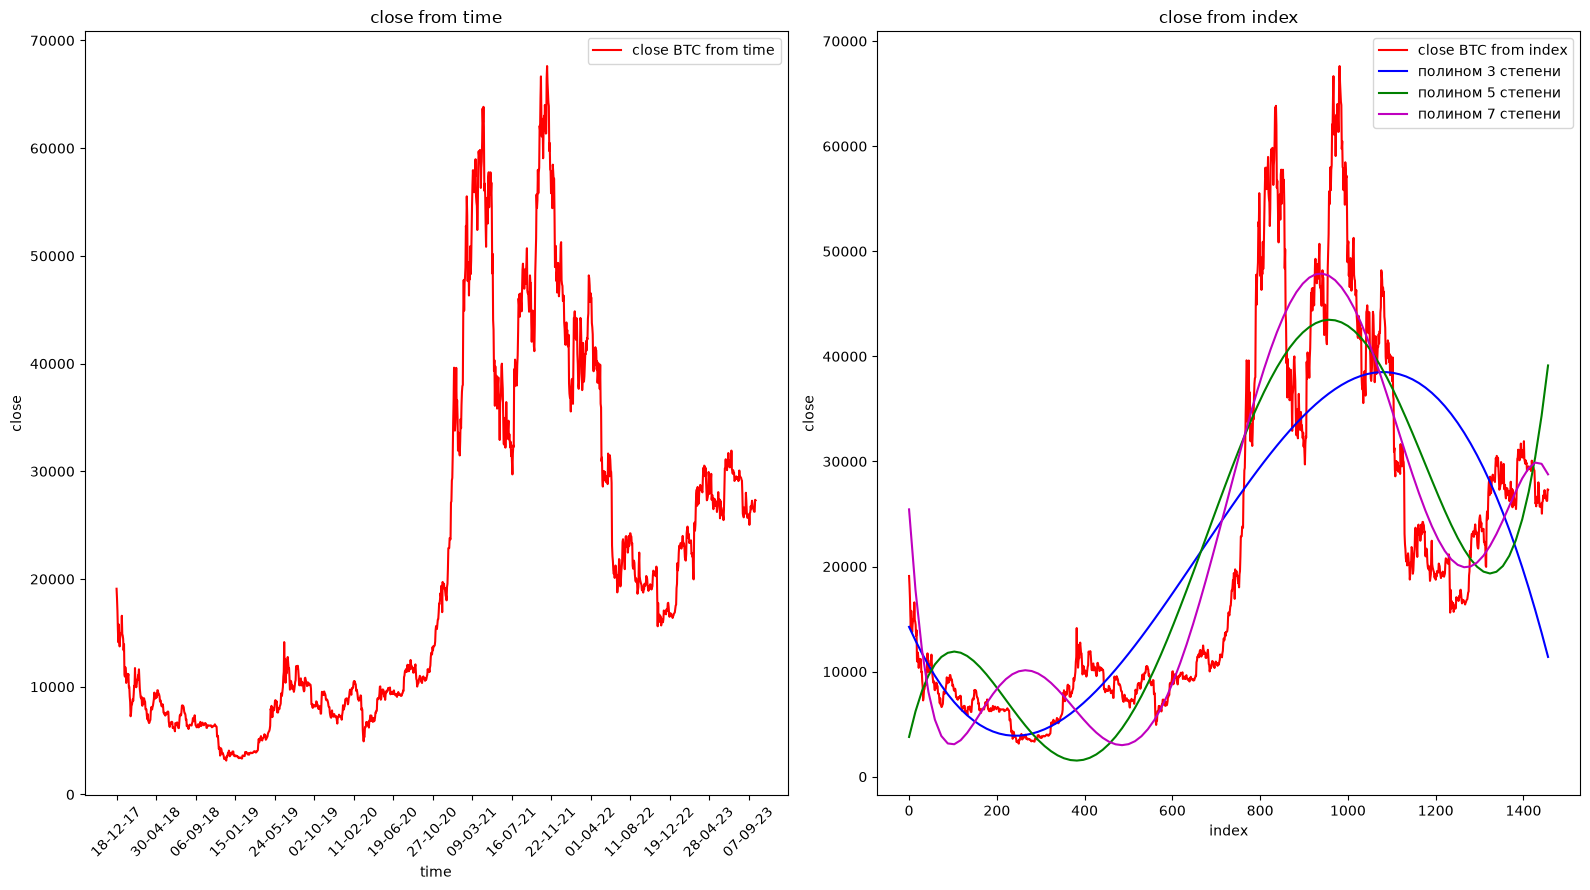

In [1]:
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd


# f = pd.read_csv('BTC_data.csv')

# close = np.array(f['close'])
# time = np.array(f['time'])
# time = pd.to_datetime(time).strftime('%d-%m-%y').tolist()

# plt.figure(figsize = (16,9))
# plt.plot(time, close, 'r', label='close BTC from time')
# plt.title('close from time')
# plt.xlabel('time')
# plt.ylabel('close')
# plt.legend()
# plt.show()



import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

f = pd.read_csv('BTC_data.csv')

close = np.array(f['close'])
time = pd.to_datetime(f['time']).dt.strftime('%d-%m-%y').tolist()
time_numbers = list(range(len(time)))

fig = plt.figure(figsize=(16, 9))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

step = 90
ax1.plot(time, close, 'r', label='close BTC from time')
ax1.set_xticks(range(0, len(time), step))
ax1.set_xticklabels([time[i] for i in range(0, len(time), step)], rotation=45)
ax1.set_title('close from time')
ax1.set_xlabel('time')
ax1.set_ylabel('close')
ax1.legend()

ax2.plot(time_numbers, close, 'r', label='close BTC from index')
# k, b = np.polyfit(time_numbers, close, 1)
# x_line = np.linspace(min(time_numbers), max(time_numbers), 100)
# ax2.plot(x_line, k * x_line + b, 'b-', label=f'МНК: y={k:.2f}x+{b:.2f}') как сделать для нескольких степеней в цикл
x_line = np.linspace(min(time_numbers), max(time_numbers), 100)
colors = {3: 'b', 5: 'g', 7: 'm'}

for degree in [3, 5, 7]:
    coeffs = np.polyfit(time_numbers, close, degree)
    y_line = np.polyval(coeffs, x_line)
    ax2.plot(x_line, y_line, colors[degree] + '-', label=f'полином {degree} степени')
    
ax2.set_title('close from index')
ax2.set_xlabel('index')
ax2.set_ylabel('close')
ax2.legend()

plt.tight_layout()
plt.show()